# Laboratorio 4 — Electrocardiograma (ECG)
## Reposo, Hiperventilación, Hipoventilación y Actividad Aeróbica — Derivaciones DI, DII y DIII

**Curso:** Introducción a Señales Biomédicas

In [28]:
pip install opensignalsreader

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks
from opensignalsreader import OpenSignalsReader

# ── Función reutilizable de análisis ─────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    b, a = butter(order, [low / (0.5 * fs), high / (0.5 * fs)], btype='band')
    return filtfilt(b, a, sig)

def analizar_ecg(path, titulo, zoom_ini=0, zoom_dur=5, zoom_fin=False):
    # ── Lectura ───────────────────────────────────────────────────────────
    acq = OpenSignalsReader(path)
    fs = acq.sampling_rate

    ecg = acq.signal()['ECG'].astype(float)
    ecg -= ecg.mean()
    t = np.arange(len(ecg)) / fs

    # ── Filtros: pasa-banda 0.5-40 Hz + notch 60 Hz (red eléctrica) ─────────
    ecg = bandpass(ecg, 0.5, 40, fs)
    b_n, a_n = iirnotch(60, 30, fs)
    ecg = filtfilt(b_n, a_n, ecg)

    # ── Detección de picos R y frecuencia cardíaca ──────────────────────────
    peaks, _ = find_peaks(ecg, distance=int(0.4 * fs), height=0.4 * ecg.max())
    rr_ms = np.diff(peaks) / fs * 1000
    fc_media = (60 / (rr_ms / 1000)).mean()

    print(f'{titulo} -> Frecuencia cardíaca media: {fc_media:.1f} bpm  (duración: {len(ecg)/fs:.1f} s)')

    # ── Gráficos: señal completa + zoom ──────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
    fig.suptitle(f'Señal ECG – {titulo}', fontsize=13, fontweight='bold')

    ax1.plot(t, ecg, color='#1a6bb5', lw=0.7)
    ax1.set_title('Señal completa', fontsize=11)
    ax1.set_xlabel('Tiempo [s]'); ax1.set_ylabel('Amplitud [mV]')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # zoom_fin=True: toma los últimos `zoom_dur` segundos en vez de partir en zoom_ini
    ini = max(0, len(ecg) / fs - zoom_dur) if zoom_fin else zoom_ini
    ini_idx = int(ini * fs)
    fin_idx = int((ini + zoom_dur) * fs)
    etiqueta_zoom = f'últimos {zoom_dur:.0f} s' if zoom_fin else f'{ini:.0f}–{ini + zoom_dur:.0f} s'

    ax2.plot(t[ini_idx:fin_idx], ecg[ini_idx:fin_idx], color='#1a6bb5', lw=0.9)
    ax2.set_title(f'Zoom – {etiqueta_zoom}', fontsize=11)
    ax2.set_xlabel('Tiempo [s]'); ax2.set_ylabel('Amplitud [mV]')
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    return {'fc_media': fc_media, 'duracion_s': len(ecg) / fs}
    
resultados = {}

## 1. Derivación DI

### 1.1 Reposo

DI – Reposo -> Frecuencia cardíaca media: 91.9 bpm  (duración: 42.5 s)


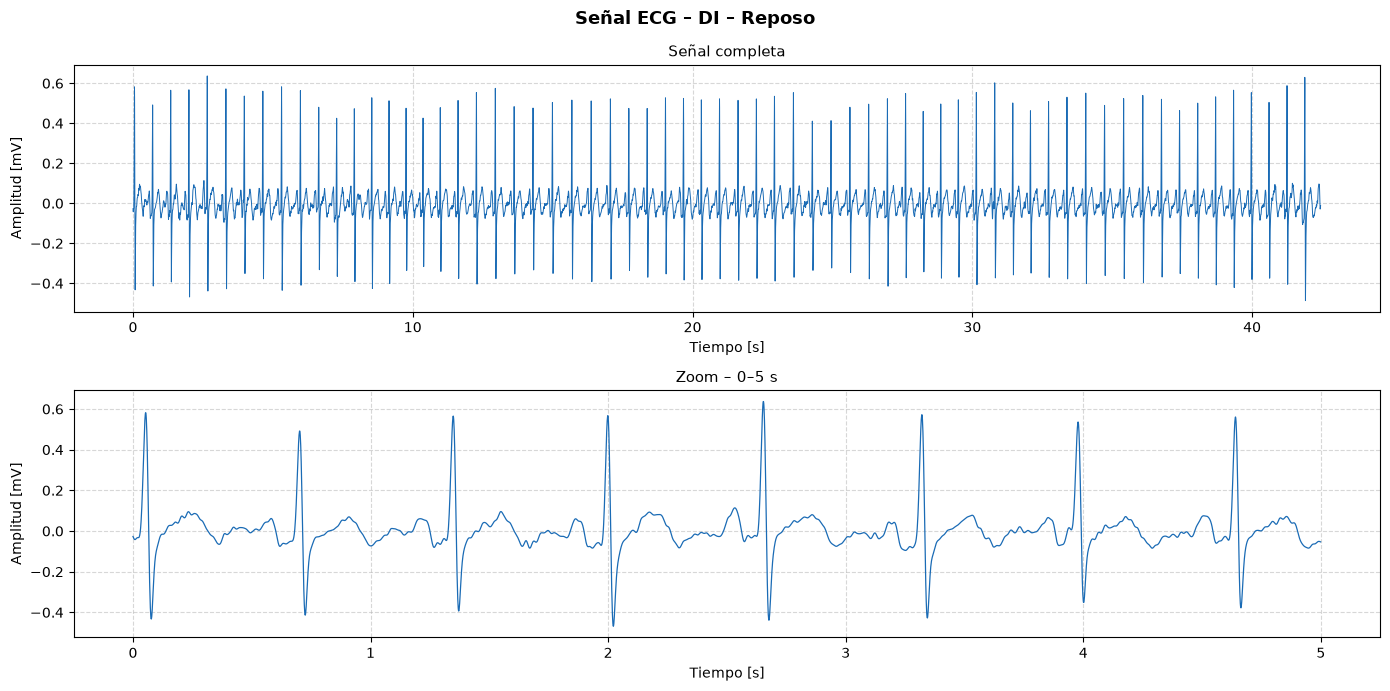

In [30]:
resultados[('DI', 'Reposo')] = analizar_ecg('Datos/DI_BASAL.txt', 'DI – Reposo')

### 1.2 Hiperventilación

DI – Hiperventilación -> Frecuencia cardíaca media: 104.0 bpm  (duración: 40.6 s)


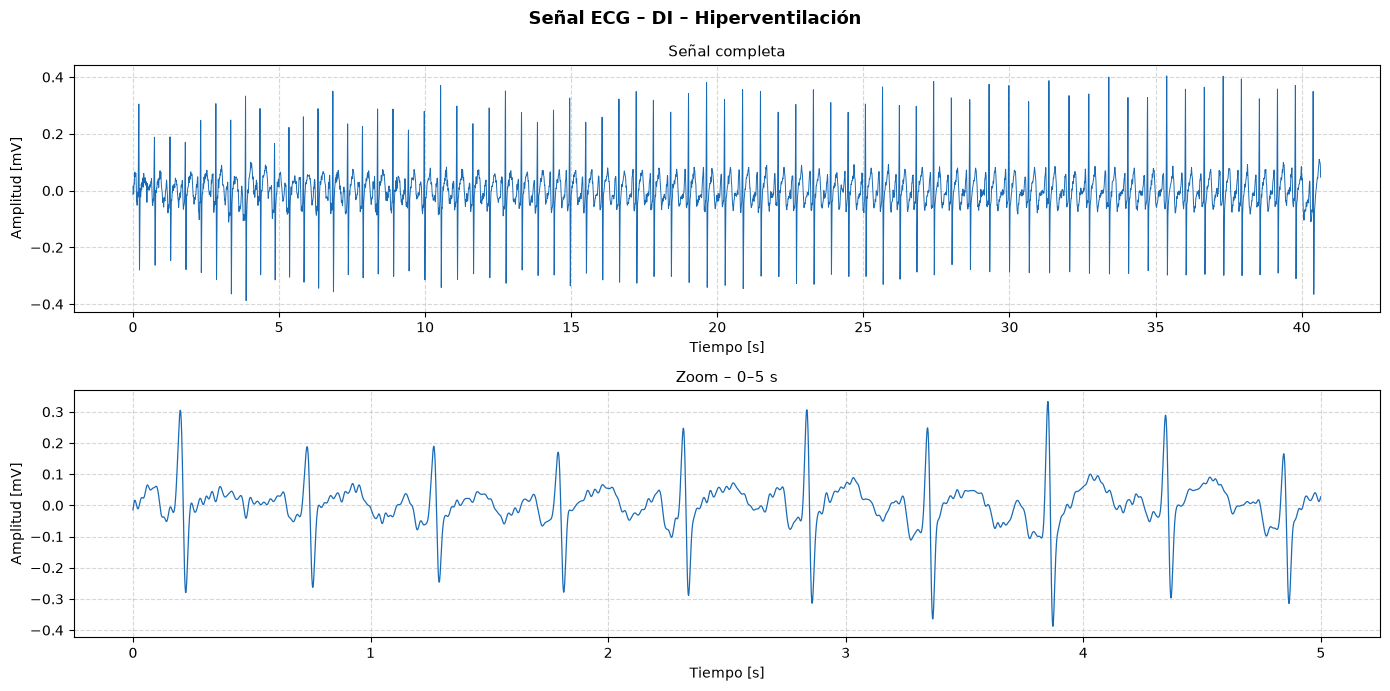

In [31]:
resultados[('DI', 'Hiperventilación')] = analizar_ecg('Datos/DI_HIPER.txt', 'DI – Hiperventilación')

### 1.3 Hipoventilación

DI – Hipoventilación -> Frecuencia cardíaca media: 87.3 bpm  (duración: 33.0 s)


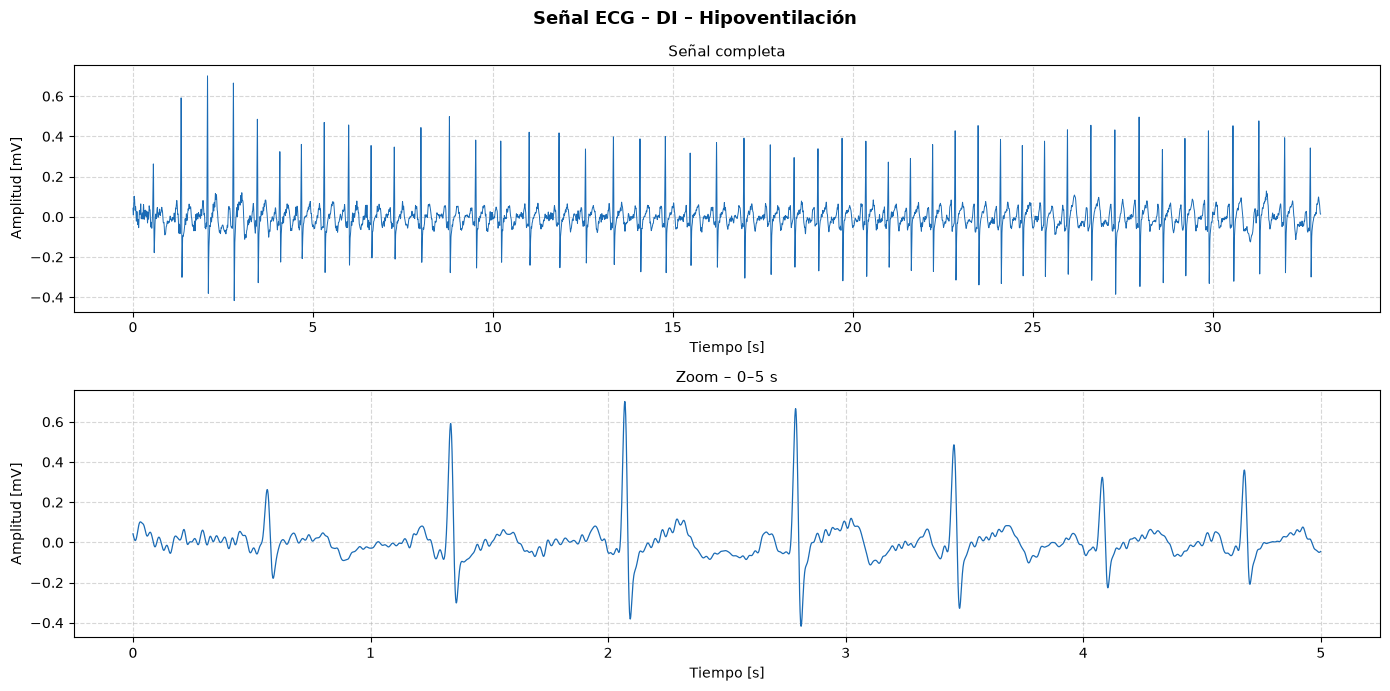

In [32]:
resultados[('DI', 'Hipoventilación')] = analizar_ecg('Datos/DI_HIPO.txt', 'DI – Hipoventilación')

### 1.4 Actividad aeróbica

DI – Actividad aeróbica -> Frecuencia cardíaca media: 109.6 bpm  (duración: 32.9 s)


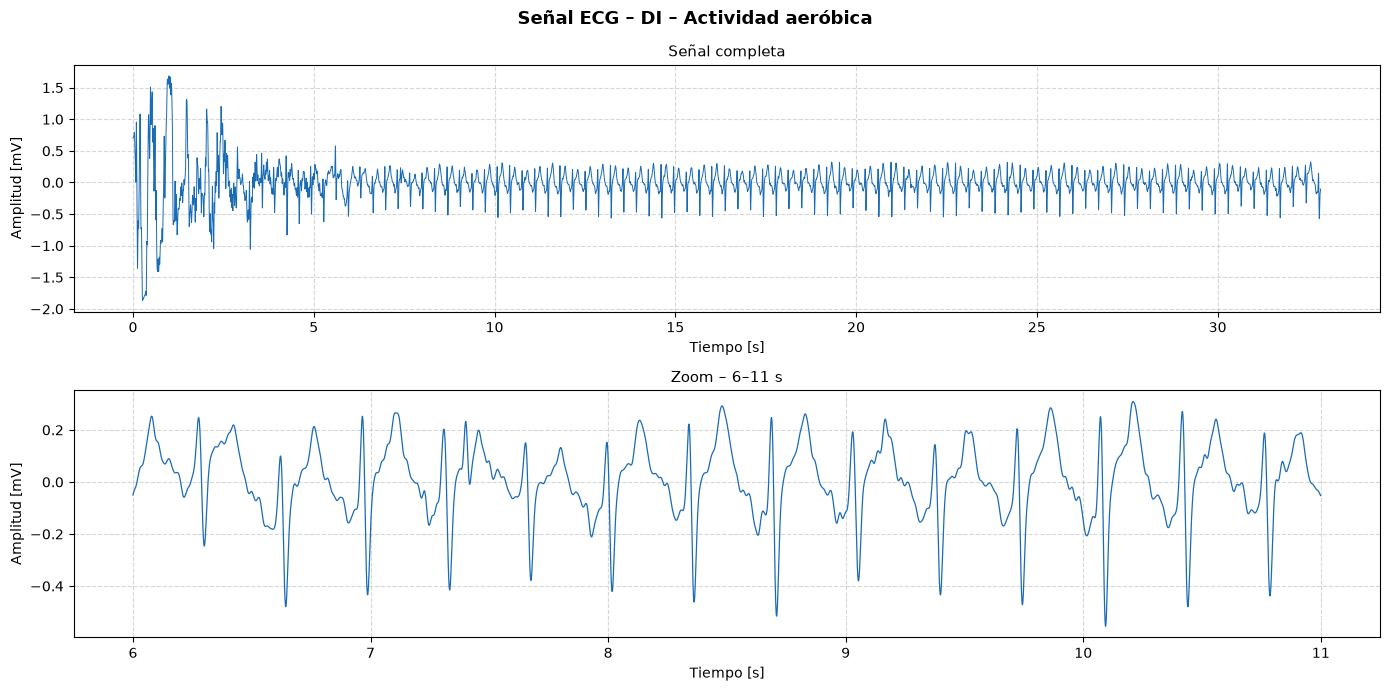

In [45]:
resultados[('DI', 'Actividad aeróbica')] = analizar_ecg('Datos/DI_ACTI.txt', 'DI – Actividad aeróbica', zoom_ini=6, zoom_dur=5)

## 2. Derivación DII

### 2.1 Reposo

DII – Reposo -> Frecuencia cardíaca media: 88.4 bpm  (duración: 38.5 s)


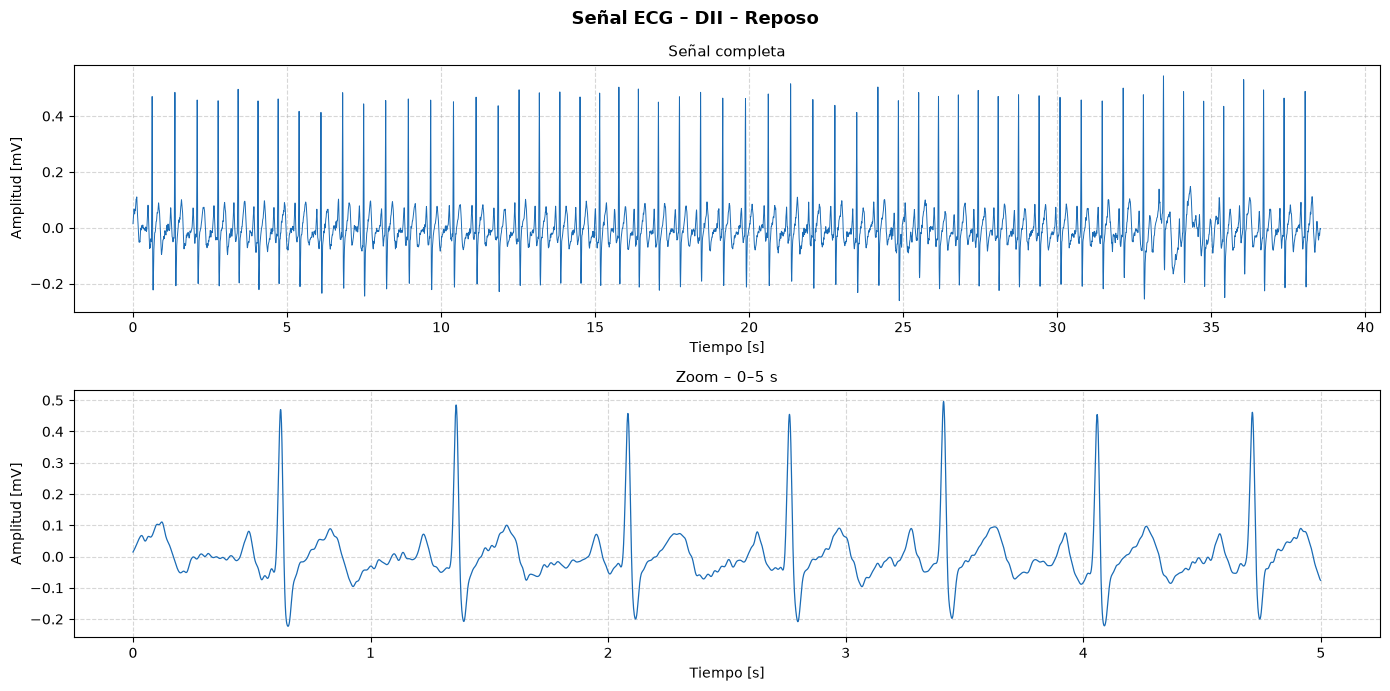

In [ ]:
resultados[('DII', 'Reposo')] = analizar_ecg('Datos/DII_BASAL.txt', 'DII – Reposo')

### 2.2 Hiperventilación

DII – Hiperventilación -> Frecuencia cardíaca media: 116.4 bpm  (duración: 31.8 s)


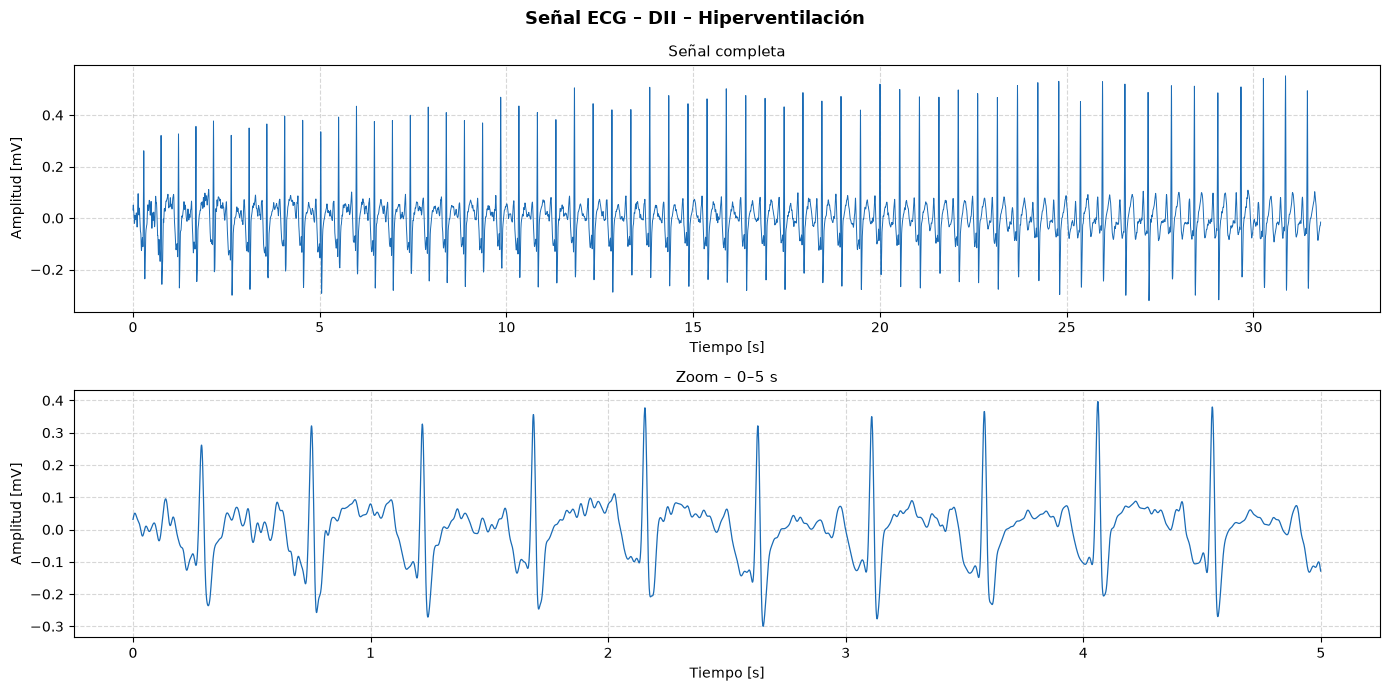

In [ ]:
resultados[('DII', 'Hiperventilación')] = analizar_ecg('Datos/DII_HIPER.txt', 'DII – Hiperventilación')

### 2.3 Hipoventilación

DII – Hipoventilación -> Frecuencia cardíaca media: 81.6 bpm  (duración: 32.1 s)


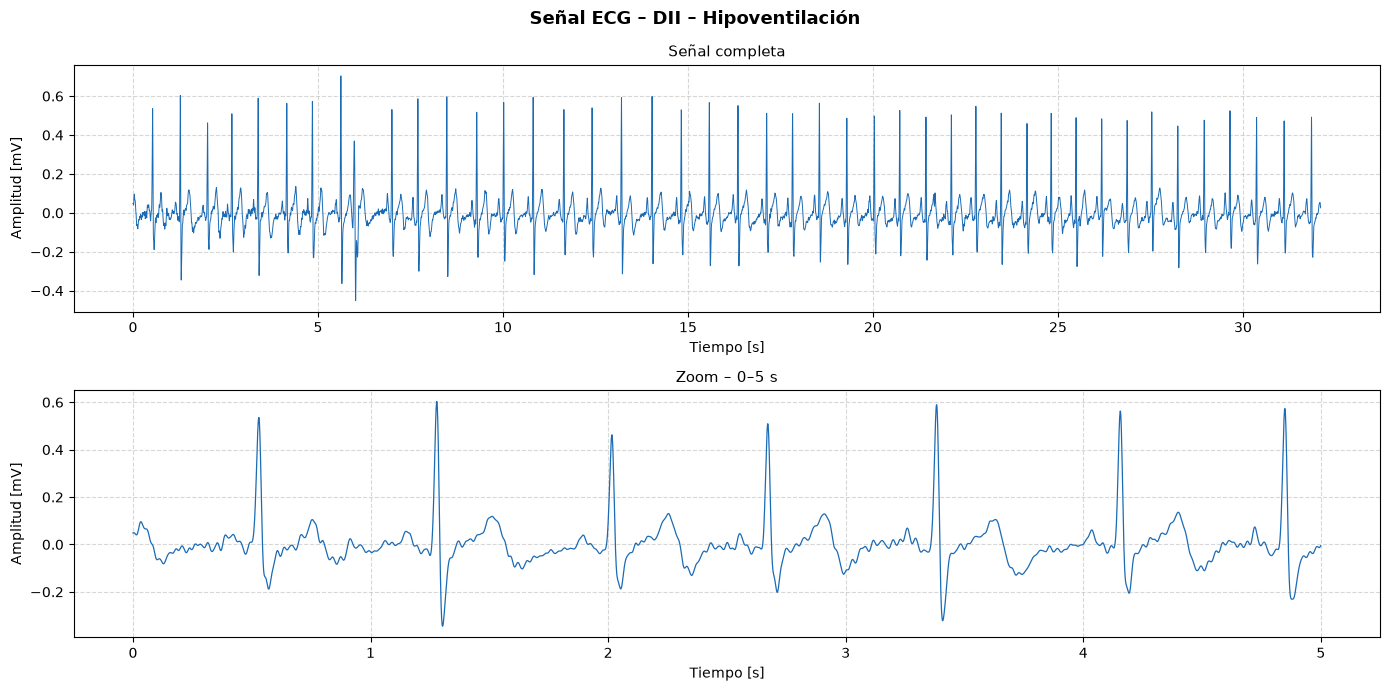

In [ ]:
resultados[('DII', 'Hipoventilación')] = analizar_ecg('Datos/DII_HIPO.txt', 'DII – Hipoventilación')

### 2.4 Actividad aeróbica

DII – Actividad aeróbica -> Frecuencia cardíaca media: 143.9 bpm  (duración: 30.6 s)


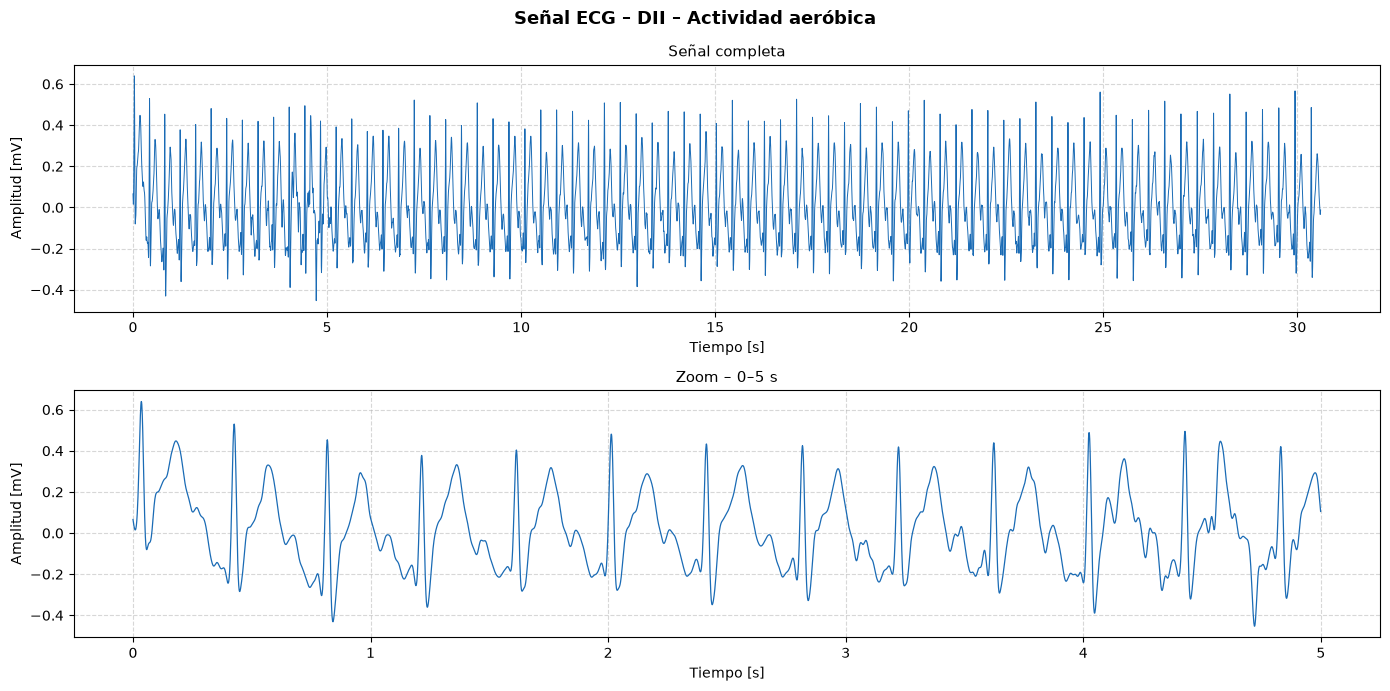

In [ ]:
resultados[('DII', 'Actividad aeróbica')] = analizar_ecg('Datos/DII_ACTI.txt', 'DII – Actividad aeróbica')

## 3. Derivación DIII

### 3.1 Reposo

DIII – Reposo -> Frecuencia cardíaca media: 90.7 bpm  (duración: 38.2 s)


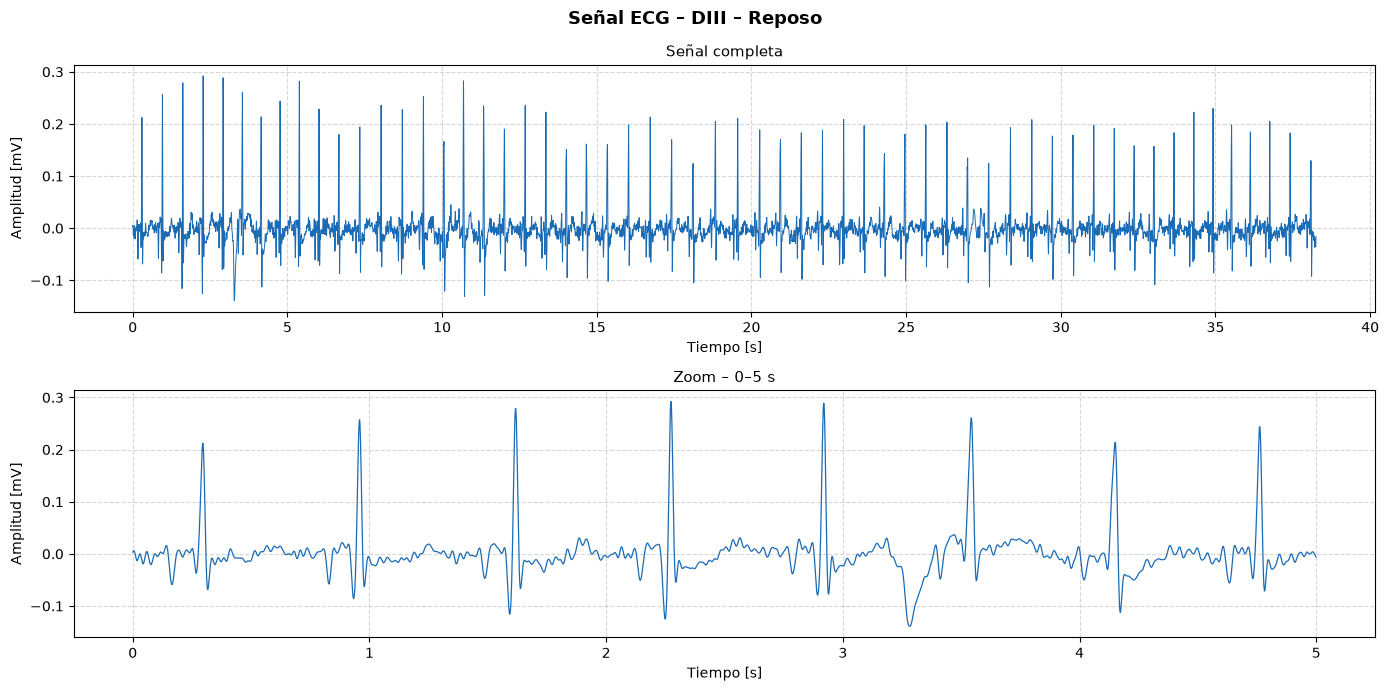

In [ ]:
resultados[('DIII', 'Reposo')] = analizar_ecg('Datos/DIII_BASAL.txt', 'DIII – Reposo')

### 3.2 Hiperventilación

DIII – Hiperventilación -> Frecuencia cardíaca media: 88.8 bpm  (duración: 72.6 s)


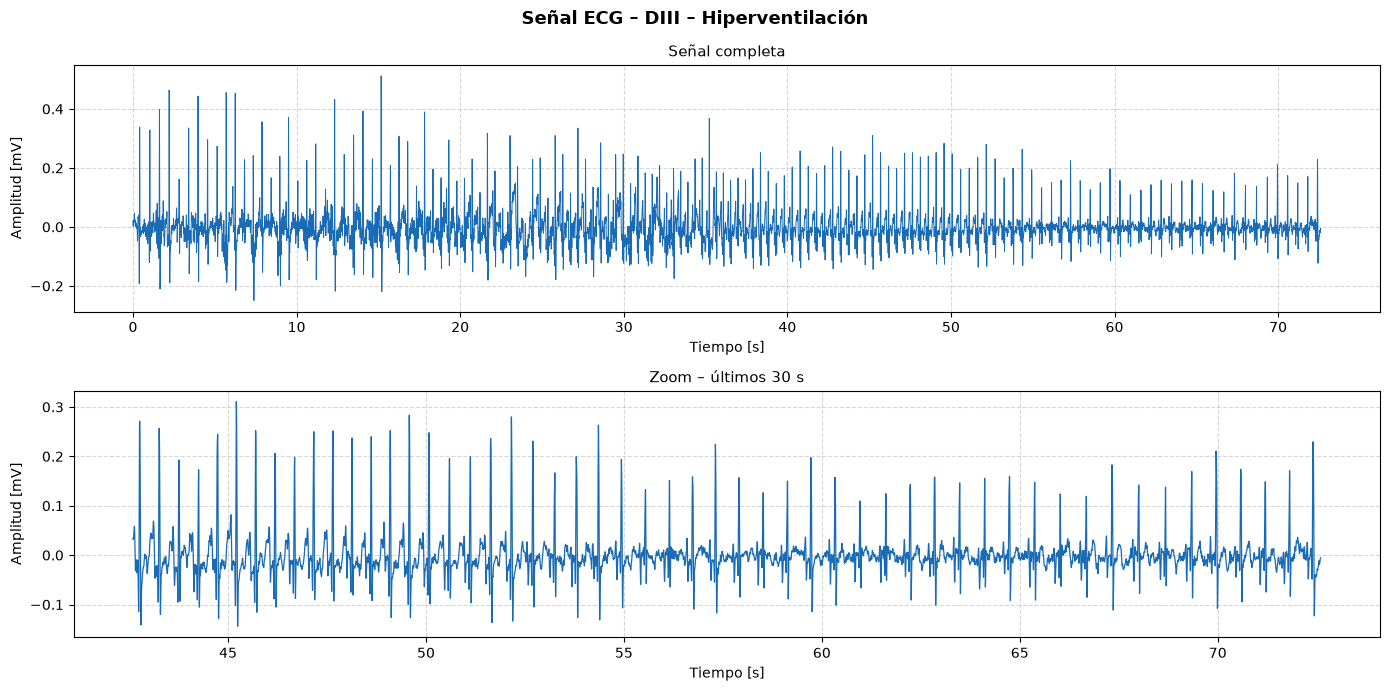

In [ ]:
resultados[('DIII', 'Hiperventilación')] = analizar_ecg('Datos/DIII_HIPER.txt', 'DIII – Hiperventilación', zoom_dur=30, zoom_fin=True)

### 3.3 Hipoventilación

DIII – Hipoventilación -> Frecuencia cardíaca media: 61.8 bpm  (duración: 33.3 s)


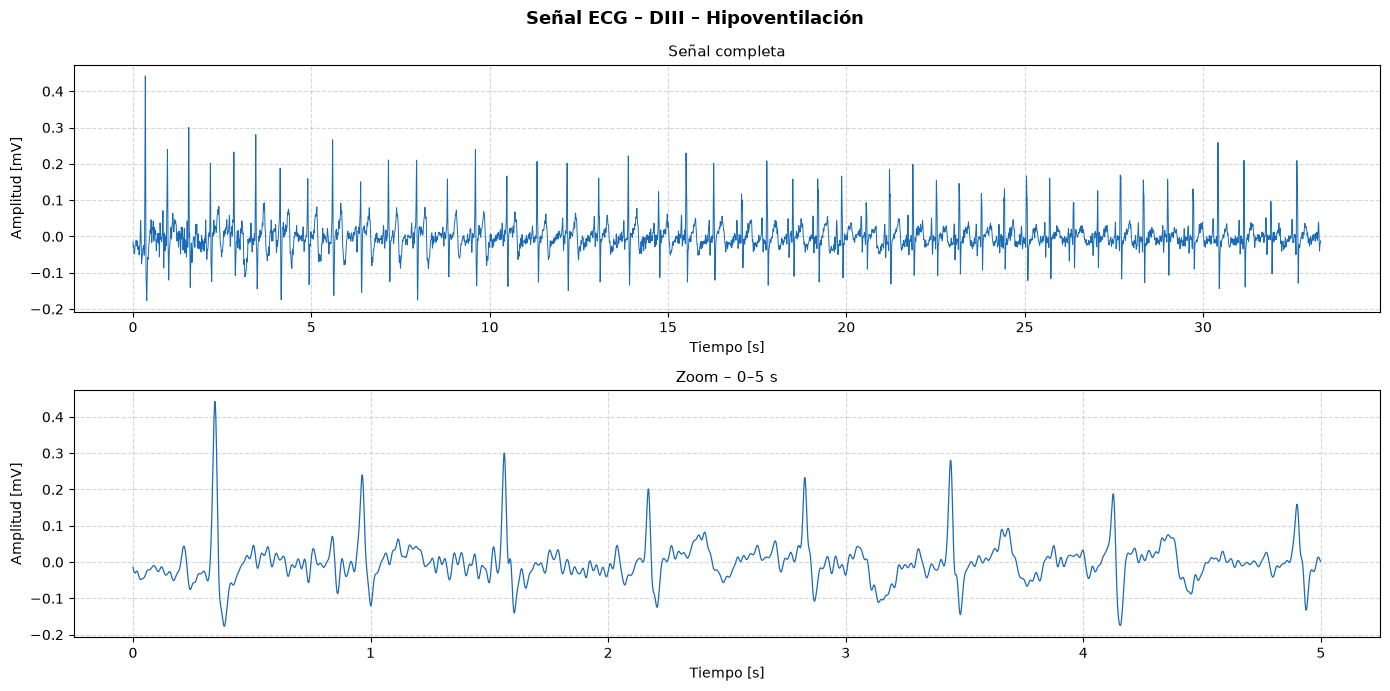

In [ ]:
resultados[('DIII', 'Hipoventilación')] = analizar_ecg('Datos/DIII_HIPO.txt', 'DIII – Hipoventilación')

### 3.4 Actividad aeróbica

DIII – Actividad aeróbica -> Frecuencia cardíaca media: 125.9 bpm  (duración: 31.2 s)


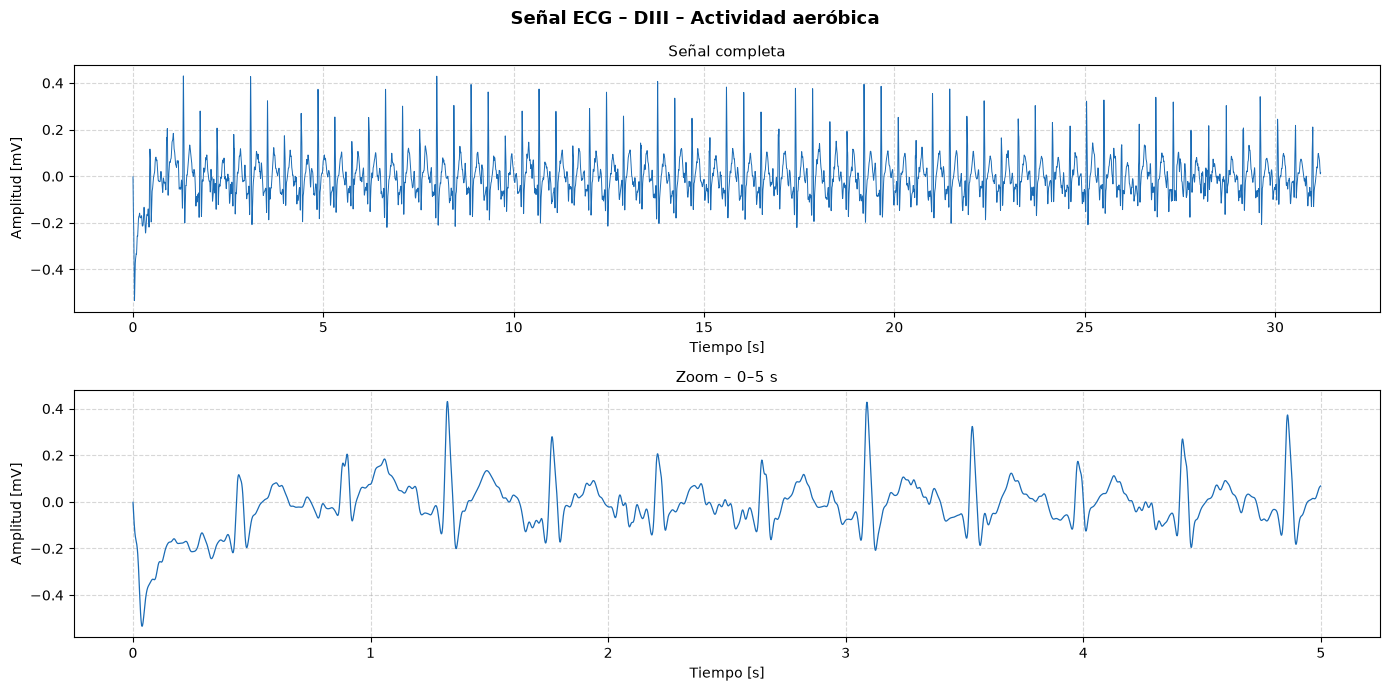

In [ ]:
resultados[('DIII', 'Actividad aeróbica')] = analizar_ecg('Datos/DIII_ACTI.txt', 'DIII – Actividad aeróbica')